                                     CVXPY                                     
                                     v1.6.5                                    
(CVXPY) Apr 14 09:57:45 AM: Your problem has 10000 variables, 1000 constraints, and 0 parameters.
(CVXPY) Apr 14 09:57:45 AM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Apr 14 09:57:45 AM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Apr 14 09:57:45 AM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Apr 14 09:57:45 AM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Apr 14 09:57:45 AM: Compiling problem (target solver=CLARA

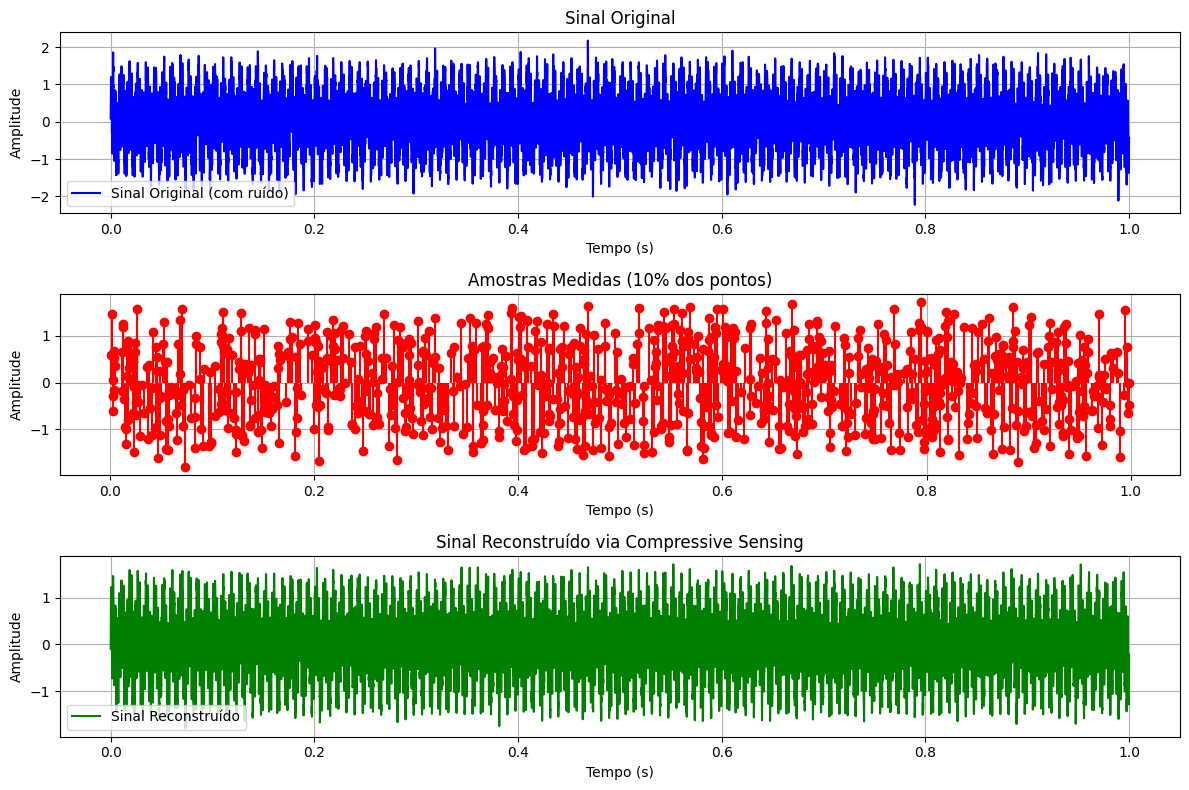

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp

# --------------------------
# 1. Simulação do Sinal
# --------------------------
fs = 10000          # Frequência de amostragem (Hz)
T = 1              # Duração do sinal (segundos)
N = int(fs * T)    # Número total de amostras
t = np.linspace(0, T, N, endpoint=False)

# Componentes senoidais do sinal
f1 = 500            # Frequência da primeira onda (Hz)
A1 = 1.0           # Amplitude da primeira onda
f2 = 120           # Frequência da segunda onda (Hz)
A2 = 0.5           # Amplitude da segunda onda

# Sinal sem ruído
sinal1 = A1 * np.sin(2 * np.pi * f1 * t)
sinal2 = A2 * np.sin(2 * np.pi * f2 * t)
sinal_limpo = sinal1 + sinal2

# Adicionando ruído branco (opcional)
nivel_ruido = 0.2
ruido = nivel_ruido * np.random.randn(N)
sinal = sinal_limpo + ruido

# --------------------------
# 2. Amostragem de 10% do sinal
# --------------------------
percentual = 0.1     # 10%
m = int(percentual * N)  # número de amostras medidos
np.random.seed(0)    # Para reprodução dos resultados

# Índices de amostragem (selecionados aleatoriamente)
indices = np.sort(np.random.choice(np.arange(N), m, replace=False))
y = sinal[indices]   # Medições do sinal

# --------------------------
# 3. Construindo a Matriz de Transformada Fourier
# --------------------------
# Criamos a matriz DFT (size N x N)
# Note que para a IDFT padrão temos: x = (1/N) * F^H * a
# onde F_{kj} = exp(-2pi i k j / N), e F^H é a transposta conjugada.
n = np.arange(N)
k = n.reshape((N, 1))
F = np.exp(-2j * np.pi * k * n / N)  # Matriz DFT

# Matriz da IDFT
F_inv = (1 / N) * np.conj(F)

# --------------------------
# 4. Resolvendo o Problema de Compressive Sensing
# --------------------------
# Variável complexa de otimização: coeficientes de Fourier "a"
a = cp.Variable(N, complex=True)

# Construindo o operador de amostragem:
# Queremos que os valores da IDFT reconstruída, 
# apenas nas posições medidas (indices), sejam iguais a y.
# Ou seja: (F_inv @ a)[indices] == y
# Para simplificar, extraímos as linhas correspondentes:
F_inv_omega = F_inv[indices, :]

# Problema de Basis Pursuit (minimização da norma l1 para promover esparsidade)
objective = cp.Minimize(cp.norm1(a))
constraints = [F_inv_omega @ a == y]
problem = cp.Problem(objective, constraints)
problem.solve(verbose=True)

# Recuperação do sinal reconstruído pela IDFT dos coeficientes otimizados
a_rec = a.value
sinal_rec = F_inv @ a_rec

# Para resultados reais (nosso sinal é real), extraímos a parte real
sinal_rec = np.real(sinal_rec)

# --------------------------
# 5. Visualização dos Resultados
# --------------------------
plt.figure(figsize=(12, 8))

# Sinal original
plt.subplot(3, 1, 1)
plt.plot(t, sinal, label='Sinal Original (com ruído)', color='blue')
plt.title('Sinal Original')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()

# Amostras medidas
plt.subplot(3, 1, 2)
plt.stem(t[indices], y, linefmt='r-', markerfmt='ro', basefmt=" ")
plt.title('Amostras Medidas (10% dos pontos)')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.grid(True)

# Sinal reconstruído por Compressive Sensing
plt.subplot(3, 1, 3)
plt.plot(t, sinal_rec, label='Sinal Reconstruído', color='green')
plt.title('Sinal Reconstruído via Compressive Sensing')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


                                     CVXPY                                     
                                     v1.6.5                                    
(CVXPY) Apr 14 10:49:36 AM: Your problem has 1000 variables, 100 constraints, and 0 parameters.
(CVXPY) Apr 14 10:49:36 AM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Apr 14 10:49:36 AM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Apr 14 10:49:36 AM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Apr 14 10:49:36 AM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Apr 14 10:49:36 AM: Compiling problem (target solver=CLARABE

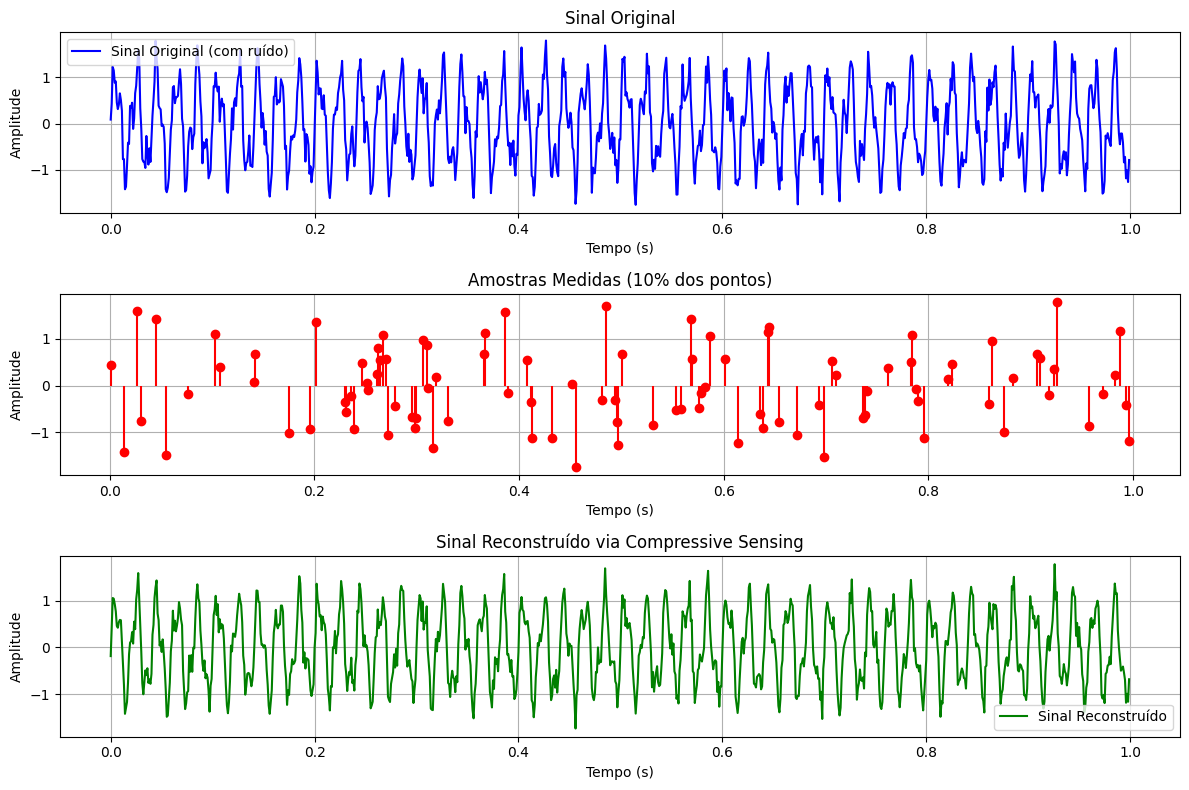

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp

# --------------------------
# 1. Simulação do Sinal
# --------------------------
fs = 1000          # Frequência de amostragem (Hz)
T = 1              # Duração do sinal (segundos)
N = int(fs * T)    # Número total de amostras
t = np.linspace(0, T, N, endpoint=False)

# Componentes senoidais do sinal
f1 = 50            # Frequência da primeira onda (Hz)
A1 = 1.0           # Amplitude da primeira onda
f2 = 120           # Frequência da segunda onda (Hz)
A2 = 0.5           # Amplitude da segunda onda

# Sinal sem ruído
sinal1 = A1 * np.sin(2 * np.pi * f1 * t)
sinal2 = A2 * np.sin(2 * np.pi * f2 * t)
sinal_limpo = sinal1 + sinal2

# Adicionando ruído branco (opcional)
nivel_ruido = 0.2
ruido = nivel_ruido * np.random.randn(N)
sinal = sinal_limpo + ruido

# --------------------------
# 2. Amostragem de 10% do sinal
# --------------------------
percentual = 0.1     # 10%
m = int(percentual * N)  # número de amostras medidos
np.random.seed(0)    # Para reprodução dos resultados

# Índices de amostragem (selecionados aleatoriamente)
indices = np.sort(np.random.choice(np.arange(N), m, replace=False))
y = sinal[indices]   # Medições do sinal

# --------------------------
# 3. Construindo a Matriz de Transformada Fourier
# --------------------------
# Criamos a matriz DFT (size N x N)
# Note que para a IDFT padrão temos: x = (1/N) * F^H * a
# onde F_{kj} = exp(-2pi i k j / N), e F^H é a transposta conjugada.
n = np.arange(N)
k = n.reshape((N, 1))
F = np.exp(-2j * np.pi * k * n / N)  # Matriz DFT

# Matriz da IDFT
F_inv = (1 / N) * np.conj(F)

# --------------------------
# 4. Resolvendo o Problema de Compressive Sensing
# --------------------------
# Variável complexa de otimização: coeficientes de Fourier "a"
a = cp.Variable(N, complex=True)

# Construindo o operador de amostragem:
# Queremos que os valores da IDFT reconstruída, 
# apenas nas posições medidas (indices), sejam iguais a y.
# Ou seja: (F_inv @ a)[indices] == y
# Para simplificar, extraímos as linhas correspondentes:
F_inv_omega = F_inv[indices, :]

# Problema de Basis Pursuit (minimização da norma l1 para promover esparsidade)
objective = cp.Minimize(cp.norm1(a))
constraints = [F_inv_omega @ a == y]
problem = cp.Problem(objective, constraints)
problem.solve(verbose=True)

# Recuperação do sinal reconstruído pela IDFT dos coeficientes otimizados
a_rec = a.value
sinal_rec = F_inv @ a_rec

# Para resultados reais (nosso sinal é real), extraímos a parte real
sinal_rec = np.real(sinal_rec)

# --------------------------
# 5. Visualização dos Resultados
# --------------------------
plt.figure(figsize=(12, 8))

# Sinal original
plt.subplot(3, 1, 1)
plt.plot(t, sinal, label='Sinal Original (com ruído)', color='blue')
plt.title('Sinal Original')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()

# Amostras medidas
plt.subplot(3, 1, 2)
plt.stem(t[indices], y, linefmt='r-', markerfmt='ro', basefmt=" ")
plt.title('Amostras Medidas (10% dos pontos)')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.grid(True)

# Sinal reconstruído por Compressive Sensing
plt.subplot(3, 1, 3)
plt.plot(t, sinal_rec, label='Sinal Reconstruído', color='green')
plt.title('Sinal Reconstruído via Compressive Sensing')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()
